# Week 2 — Exploratory Data Analysis

## Credit Card Fraud Detection

This notebook performs exploratory data analysis on the Credit Card Transactions Fraud Detection dataset.

The analysis focuses on understanding transaction characteristics, identifying relationships among variables, exploring temporal and geographic patterns, and examining factors associated with fraudulent transactions.

The analysis is divided into:

- Dataset Understanding and Data Quality
- Multivariate Analysis
- Fraud-Specific Analysis and Key Findings

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Dataset Loading

The training dataset `fraudTrain.csv` is loaded using Pandas for exploratory analysis.

In [3]:
df = pd.read_csv("../archive (2)/fraudTrain.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 2. Dataset Understanding

Before performing statistical and visual analysis, the structure, dimensions, data types, and quality of the dataset are examined.

In [4]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
print("Dataset Shape:", df.shape)
print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1296675, 23)

Number of Rows: 1296675
Number of Columns: 23


### 2.1 Dataset Structure and Variables

The dataset contains transaction, customer, demographic, geographic, temporal, and fraud-related variables. The column names and their corresponding data types are examined below.

In [6]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

## 3. Data Quality Assessment

The dataset is checked for missing values and duplicate records before performing further analysis.

In [8]:
missing_values = df.isnull().sum()

print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
Series([], dtype: int64)


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 4. Feature Engineering for Temporal Analysis

The transaction timestamp is converted into datetime format. Additional temporal variables such as hour, day, month, and day of the week are extracted to investigate time-based fraud patterns.

In [10]:
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"]
)

In [11]:
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day"] = df["trans_date_trans_time"].dt.day
df["month"] = df["trans_date_trans_time"].dt.month
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["day_name"] = df["trans_date_trans_time"].dt.day_name()

In [12]:
df[
    [
        "trans_date_trans_time",
        "hour",
        "day",
        "month",
        "day_of_week",
        "day_name"
    ]
].head()

,trans_date_trans_time,hour,day,month,day_of_week,day_name
0,2019-01-01 00:00:18,0,1,1,1,Tuesday
1,2019-01-01 00:00:44,0,1,1,1,Tuesday
2,2019-01-01 00:00:51,0,1,1,1,Tuesday
3,2019-01-01 00:01:16,0,1,1,1,Tuesday
4,2019-01-01 00:03:06,0,1,1,1,Tuesday


# Part 4 — Multivariate Analysis

Multivariate analysis examines relationships involving multiple variables simultaneously. This section investigates numerical relationships, transaction characteristics, demographic factors, temporal patterns, and geographic information in relation to fraud.

## 4.1 Correlation Analysis

A correlation matrix is used to examine the strength and direction of linear relationships among selected numerical variables, including transaction amount, geographic coordinates, city population, and fraud status.

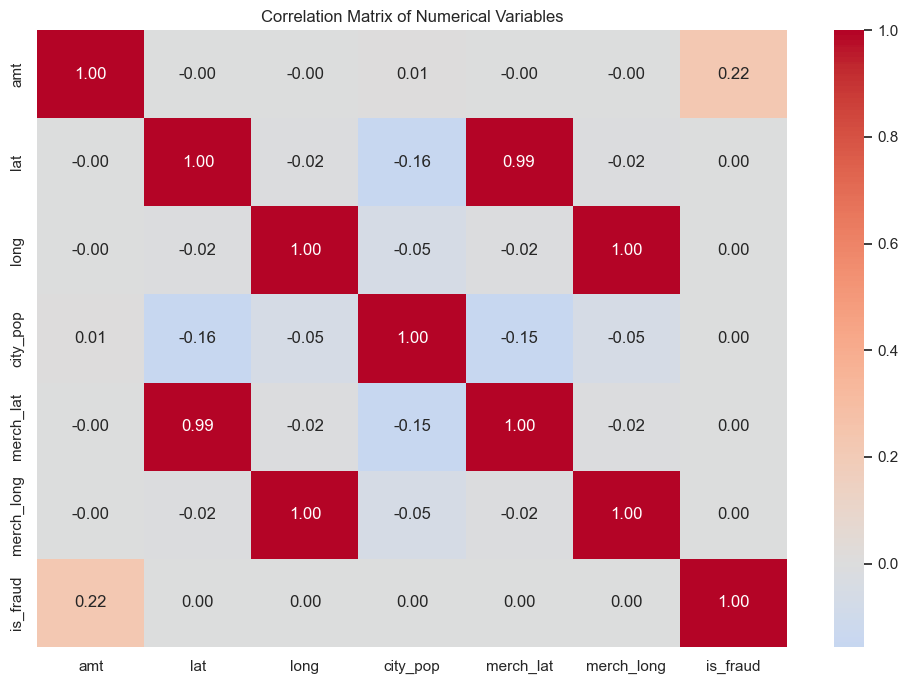

In [13]:
numeric_cols = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long",
    "is_fraud"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Observation

The correlation matrix provides an overview of the linear associations among the selected numerical variables. Stronger positive or negative correlation values indicate stronger linear relationships, while values closer to zero indicate weaker linear relationships.

Correlation alone does not imply causation.

## 4.2 Transaction Amount and Fraud Status

Transaction amount is compared across legitimate and fraudulent transactions to examine whether their distributions differ.

A violin plot is used because it displays the distribution shape as well as central tendency and spread.

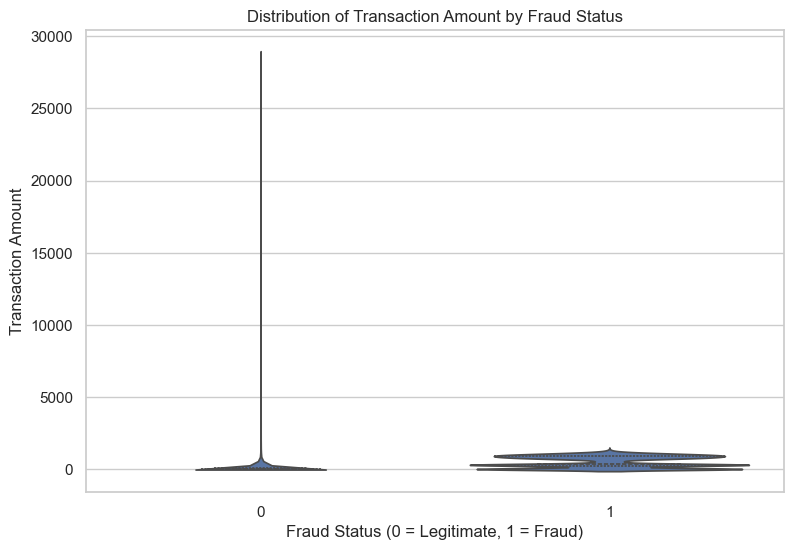

In [14]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x="is_fraud",
    y="amt",
    inner="quartile"
)

plt.title("Distribution of Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

### Observation

The violin plot allows comparison of the distribution of transaction amounts between legitimate and fraudulent transactions. Differences in the location, spread, and shape of the distributions can indicate whether transaction amount is associated with fraud status.

## 4.3 Transaction Category, Amount, and Fraud

This analysis combines transaction category, transaction amount, and fraud status to examine whether the relationship between transaction amount and fraud varies across different transaction categories.

In [15]:
category_amount = (
    df.groupby(["category", "is_fraud"])["amt"]
      .mean()
      .reset_index()
)

category_amount

,category,is_fraud,amt
0,entertainment,0,63.118913
1,entertainment,1,503.535579
2,food_dining,0,50.972816
3,food_dining,1,120.076954
4,gas_transport,0,63.675782
5,gas_transport,1,12.288204
6,grocery_net,0,53.792817
7,grocery_net,1,12.162836
8,grocery_pos,0,114.172234
9,grocery_pos,1,311.989616


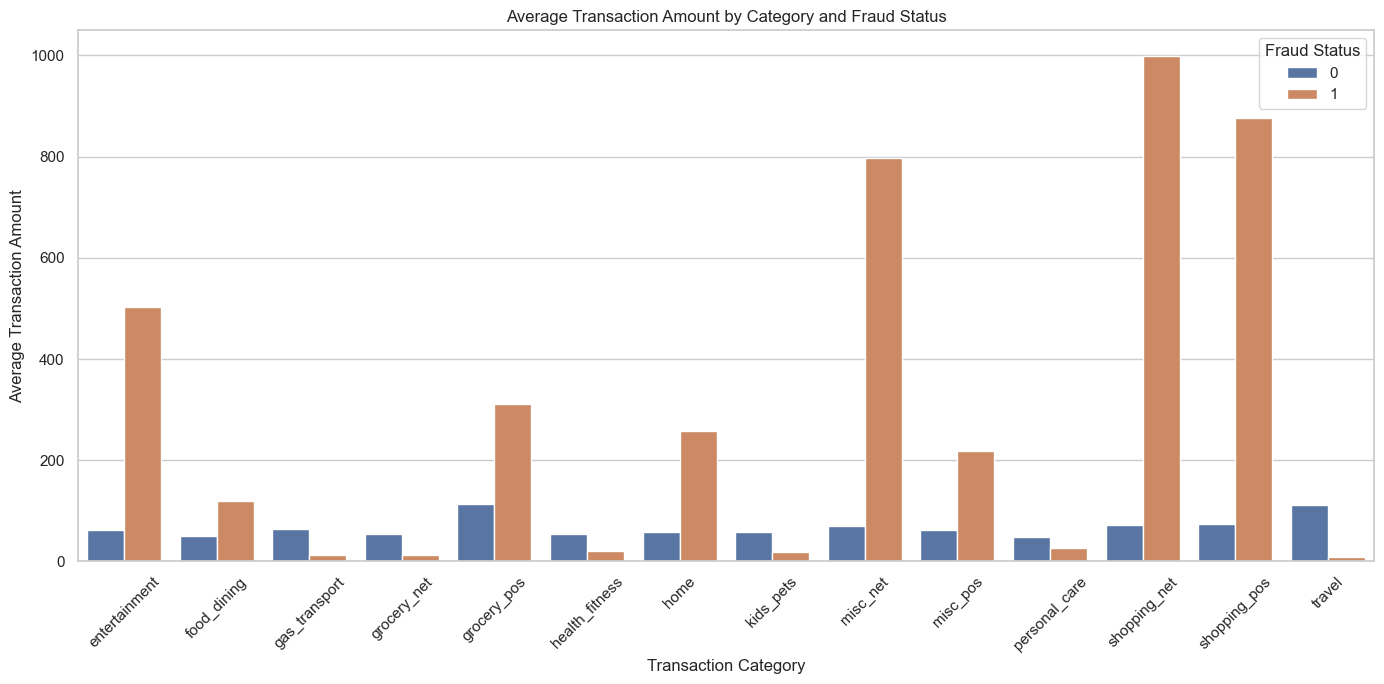

In [16]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=category_amount,
    x="category",
    y="amt",
    hue="is_fraud"
)

plt.title("Average Transaction Amount by Category and Fraud Status")
plt.xlabel("Transaction Category")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=45)
plt.legend(title="Fraud Status")

plt.tight_layout()
plt.show()

### Observation

The comparison shows how average transaction amounts vary across transaction categories and fraud status. Differences between legitimate and fraudulent transactions can be examined within each category.

## 4.4 Transaction Category, Gender, and Fraud

This analysis examines the interaction between transaction category, customer gender, and fraud rate. It helps identify whether fraud patterns vary across transaction categories for different gender groups.

In [17]:
category_gender_fraud = (
    df.groupby(["category", "gender", "is_fraud"])
      .size()
      .reset_index(name="transaction_count")
)

category_gender_fraud.head()

,category,gender,is_fraud,transaction_count
0,entertainment,F,0,48043
1,entertainment,F,1,146
2,entertainment,M,0,45738
3,entertainment,M,1,87
4,food_dining,F,0,48273


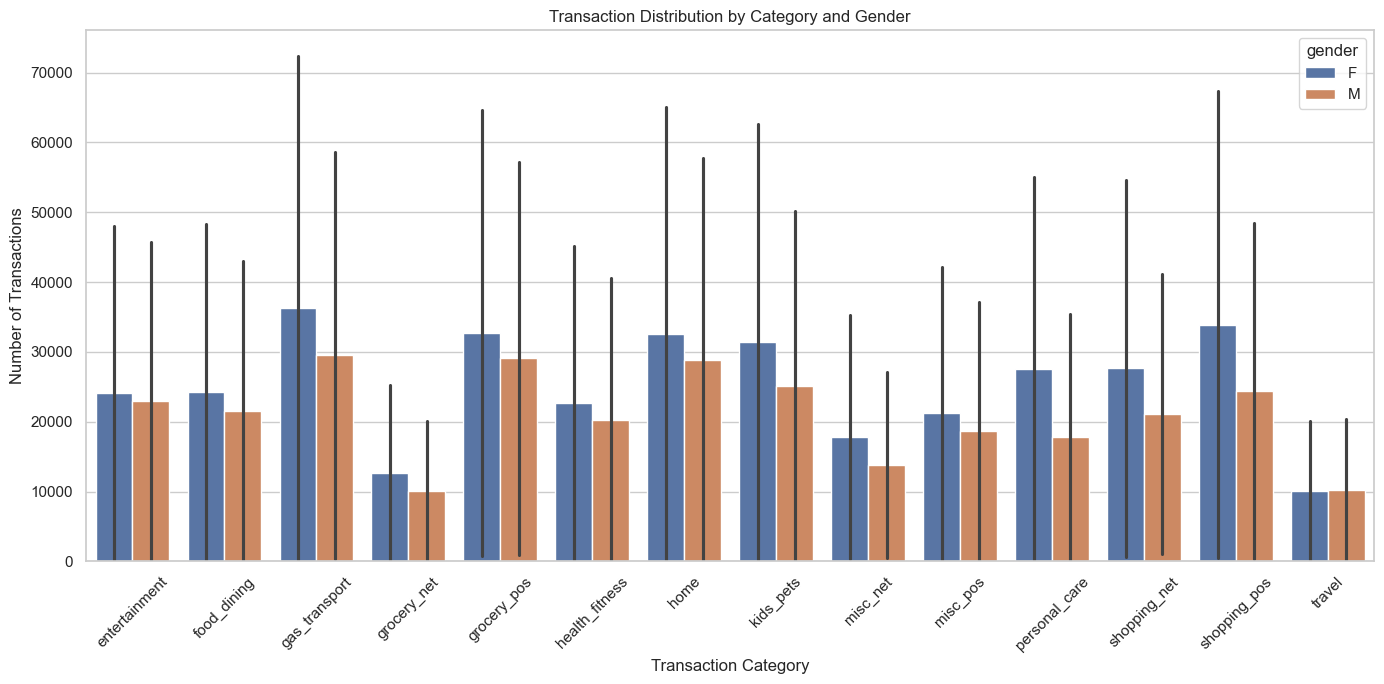

In [18]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=category_gender_fraud,
    x="category",
    y="transaction_count",
    hue="gender"
)

plt.title("Transaction Distribution by Category and Gender")
plt.xlabel("Transaction Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The visualization compares fraud rates across transaction categories and gender groups. Differences in fraud rates can be examined within each category rather than considering gender or category independently.

In [19]:
fraud_rate_category_gender = (
    df.groupby(["category", "gender"])["is_fraud"]
      .mean()
      .reset_index()
)

fraud_rate_category_gender["fraud_rate_percent"] = (
    fraud_rate_category_gender["is_fraud"] * 100
)

fraud_rate_category_gender

,category,gender,is_fraud,fraud_rate_percent
0,entertainment,F,0.003030,0.302974
1,entertainment,M,0.001899,0.189853
2,food_dining,F,0.002397,0.239724
3,food_dining,M,0.000813,0.081259
4,gas_transport,F,0.003509,0.350916
5,gas_transport,M,0.006153,0.615338
6,grocery_net,F,0.002255,0.225528
7,grocery_net,M,0.003816,0.381604
8,grocery_pos,F,0.011481,1.148107
9,grocery_pos,M,0.017037,1.703706


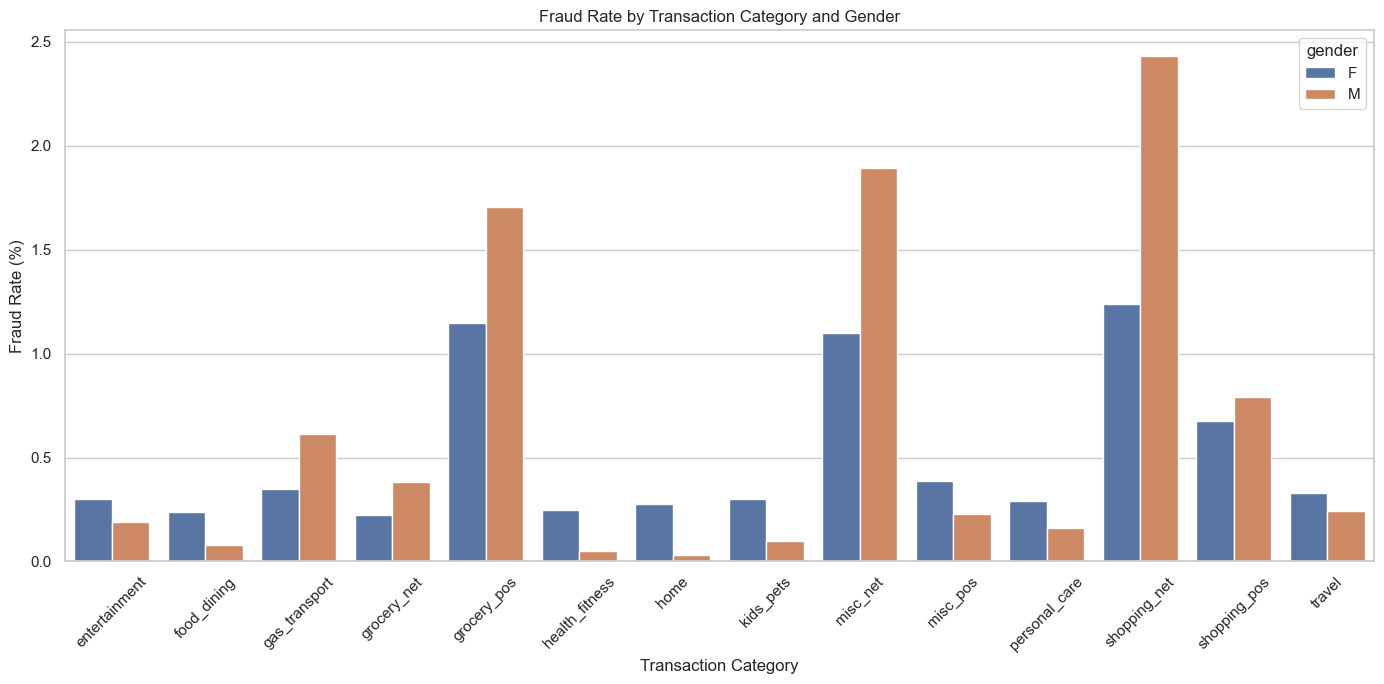

In [20]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=fraud_rate_category_gender,
    x="category",
    y="fraud_rate_percent",
    hue="gender"
)

plt.title("Fraud Rate by Transaction Category and Gender")
plt.xlabel("Transaction Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4.5 Temporal Analysis — Fraud Rate by Hour

Transaction time is analyzed to determine whether the proportion of fraudulent transactions changes across different hours of the day.

In [21]:
hourly_fraud = (
    df.groupby("hour")["is_fraud"]
      .mean()
      .reset_index()
)

hourly_fraud["fraud_rate_percent"] = (
    hourly_fraud["is_fraud"] * 100
)

hourly_fraud

,hour,is_fraud,fraud_rate_percent
0,0,0.014940,1.494047
1,1,0.015349,1.534909
2,2,0.014652,1.465210
3,3,0.014239,1.423929
4,4,0.001099,0.109882
5,5,0.001423,0.142278
6,6,0.000946,0.094563
7,7,0.001327,0.132692
8,8,0.001153,0.115281
9,9,0.001114,0.111414


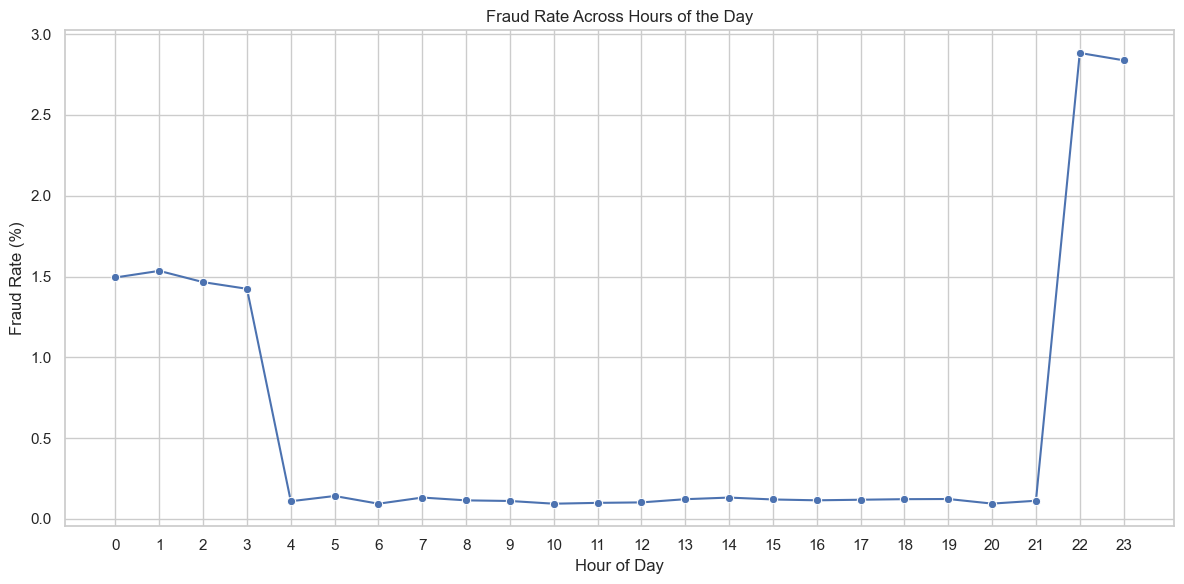

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_fraud,
    x="hour",
    y="fraud_rate_percent",
    marker="o"
)

plt.title("Fraud Rate Across Hours of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

### Observation

The line plot shows how the observed fraud rate changes throughout the day. Peaks and lower points indicate hours where the proportion of fraudulent transactions is relatively higher or lower within this dataset.

## 4.6 Transaction Category, Hour, and Fraud

A heatmap is used to examine fraud rate simultaneously across transaction categories and hours of the day.

This provides a multivariate view of temporal and categorical fraud patterns.

In [23]:
hour_category_fraud = (
    df.groupby(["hour", "category"])["is_fraud"]
      .mean()
      .reset_index()
)

hour_category_fraud["fraud_rate_percent"] = (
    hour_category_fraud["is_fraud"] * 100
)

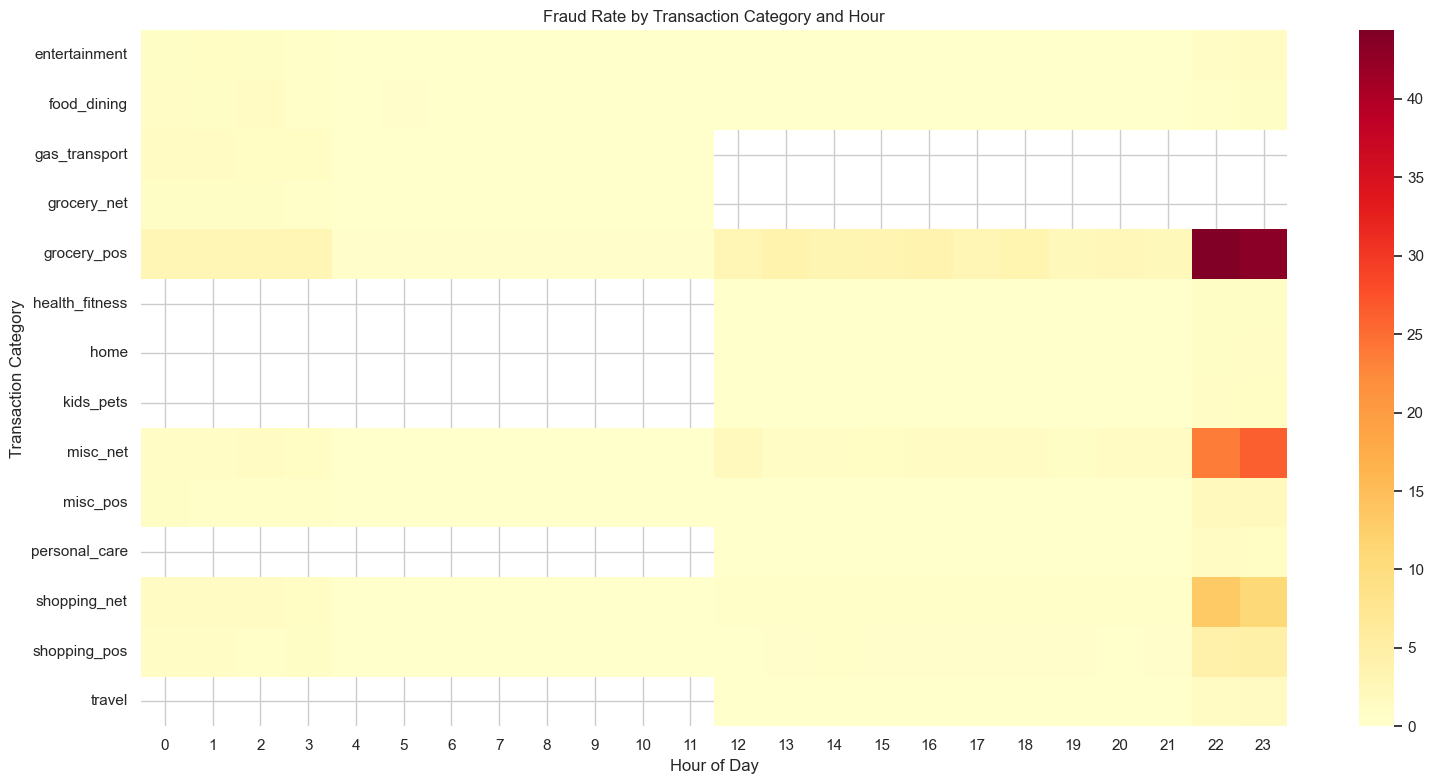

In [24]:
heatmap_data = hour_category_fraud.pivot(
    index="category",
    columns="hour",
    values="fraud_rate_percent"
)

plt.figure(figsize=(16, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False
)

plt.title("Fraud Rate by Transaction Category and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Category")

plt.tight_layout()
plt.show()

### Observation

The heatmap highlights variations in fraud rate across combinations of transaction category and hour. Areas with relatively higher values indicate combinations associated with higher observed fraud rates in the dataset.

## 4.7 Geographic Analysis

The dataset contains customer and merchant latitude and longitude coordinates. These coordinates are used to calculate the approximate geographic distance between the customer and merchant locations.

The Haversine formula is used to calculate the distance in kilometres.

In [27]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers

    # Convert degrees to radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # Differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return R * c

In [28]:
df["customer_merchant_distance_km"] = haversine_distance(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

In [29]:
df[
    [
        "lat",
        "long",
        "merch_lat",
        "merch_long",
        "customer_merchant_distance_km",
        "is_fraud"
    ]
].head()

,lat,long,merch_lat,merch_long,customer_merchant_distance_km,is_fraud
0,36.0788,-81.1781,36.011293,-82.048315,78.597568,0
1,48.8878,-118.2105,49.159047,-118.186462,30.212176,0
2,42.1808,-112.2620,43.150704,-112.154481,108.206083,0
3,46.2306,-112.1138,47.034331,-112.561071,95.673231,0
4,38.4207,-79.4629,38.674999,-78.632459,77.556744,0


In [30]:
print(df["customer_merchant_distance_km"].describe())

count    1.296675e+06
mean     7.611465e+01
std      2.911693e+01
min      2.225452e-02
25%      5.533491e+01
50%      7.823175e+01
75%      9.850327e+01
max      1.521172e+02
Name: customer_merchant_distance_km, dtype: float64


### Derived Feature: Customer–Merchant Distance

The calculated distance provides an additional variable for investigating whether geographic separation between the customer and merchant locations is associated with fraudulent transactions.

## 4.8 Customer–Merchant Distance and Fraud

The distribution of customer–merchant distance is compared between legitimate and fraudulent transactions using a box plot.

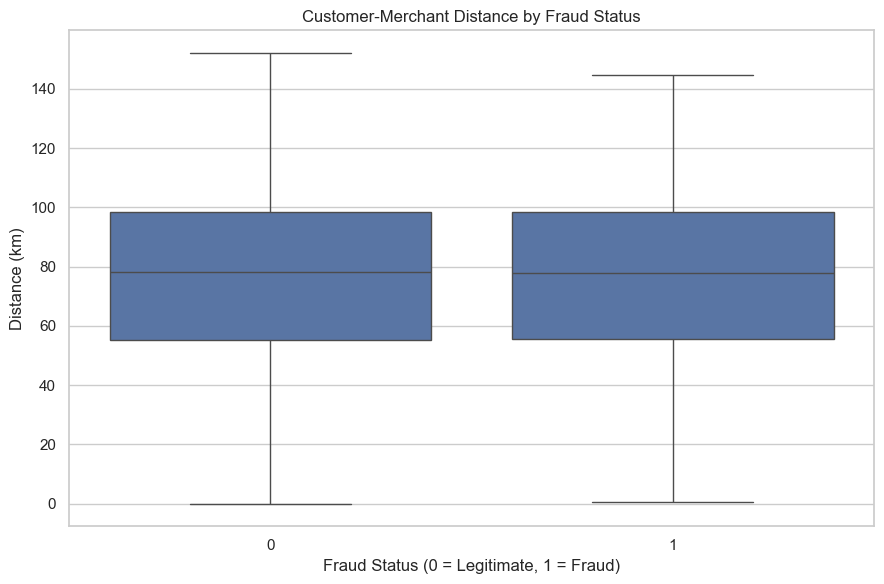

In [31]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="customer_merchant_distance_km"
)

plt.title("Customer-Merchant Distance by Fraud Status")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Distance (km)")

plt.tight_layout()
plt.show()

### Observation

The box plot compares the median, spread, and potential outliers of customer–merchant distance for legitimate and fraudulent transactions. Differences between the two groups can indicate whether transaction distance may be useful for distinguishing fraud patterns in this dataset.

# Part 5 — Fraud-Specific Analysis and Key Findings

This section focuses specifically on fraudulent transactions. Fraud rates are examined across transaction categories, time periods, geographic locations, and transaction amount ranges to identify patterns that may be relevant to fraud detection.

In [32]:
fraud_counts = df["is_fraud"].value_counts()

print(fraud_counts)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64


In [33]:
fraud_percent = df["is_fraud"].value_counts(normalize=True) * 100

print(fraud_percent)

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


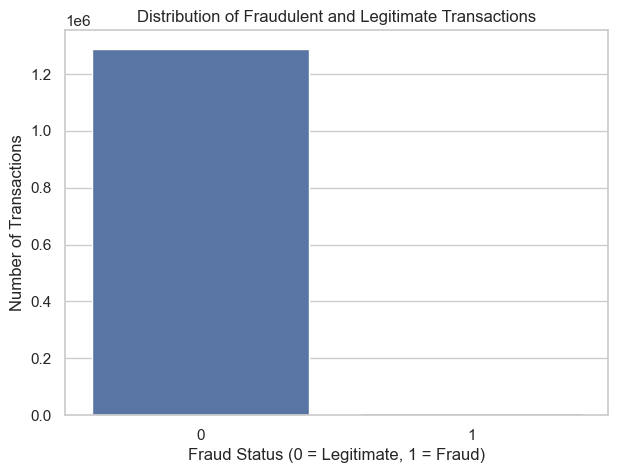

In [34]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_fraud"
)

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [35]:
fraud_by_category = (
    df.groupby("category")["is_fraud"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fraud_by_category["fraud_rate_percent"] = (
    fraud_by_category["is_fraud"] * 100
)

fraud_by_category

,category,is_fraud,fraud_rate_percent
0,shopping_net,0.017561,1.756149
1,misc_net,0.014458,1.445795
2,grocery_pos,0.014098,1.409761
3,shopping_pos,0.007225,0.722538
4,gas_transport,0.004694,0.469394
5,misc_pos,0.003139,0.313853
6,grocery_net,0.002948,0.294817
7,travel,0.002864,0.286370
8,entertainment,0.002478,0.247835
9,personal_care,0.002424,0.242403


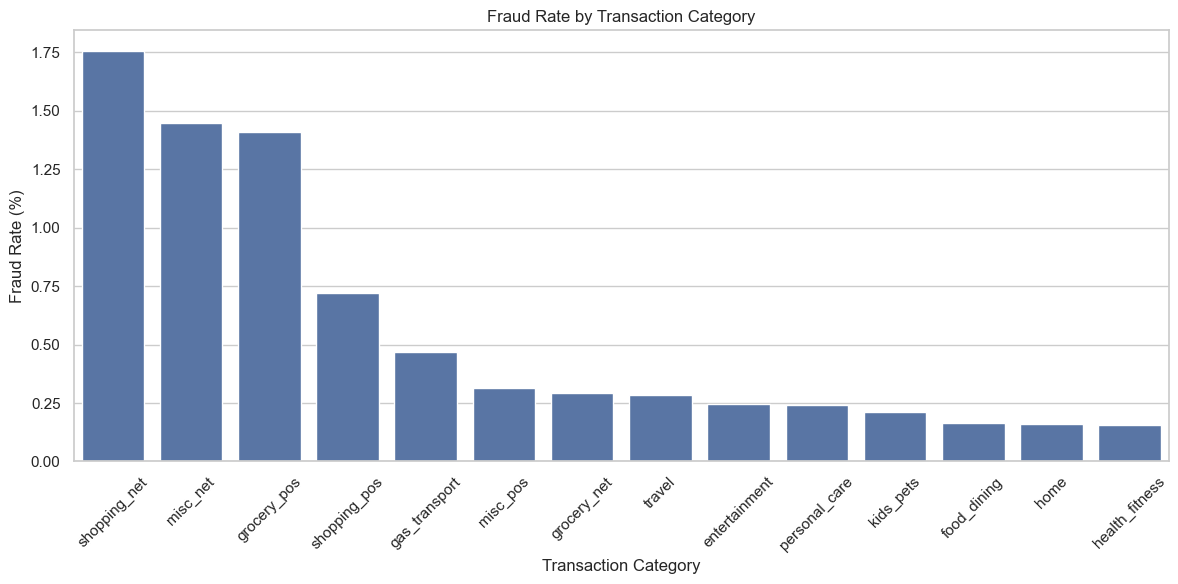

In [36]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=fraud_by_category,
    x="category",
    y="fraud_rate_percent"
)

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Transaction Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [37]:
day_fraud = (
    df.groupby("day_name")["is_fraud"]
      .mean()
      .reset_index()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_fraud["day_name"] = pd.Categorical(
    day_fraud["day_name"],
    categories=day_order,
    ordered=True
)

day_fraud = day_fraud.sort_values("day_name")

day_fraud["fraud_rate_percent"] = (
    day_fraud["is_fraud"] * 100
)

day_fraud

,day_name,is_fraud,fraud_rate_percent
1,Monday,0.004648,0.464838
5,Tuesday,0.005835,0.583547
6,Wednesday,0.006554,0.655360
4,Thursday,0.006844,0.684387
0,Friday,0.007086,0.708600
2,Saturday,0.006106,0.610578
3,Sunday,0.004853,0.485276


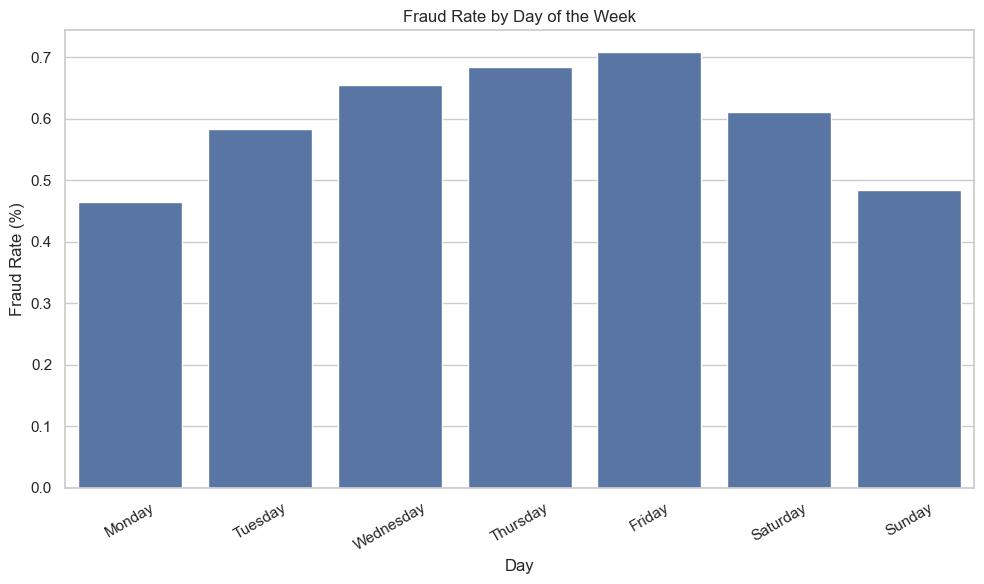

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=day_fraud,
    x="day_name",
    y="fraud_rate_percent"
)

plt.title("Fraud Rate by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [39]:
state_fraud = (
    df.groupby("state")["is_fraud"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

state_fraud["fraud_rate_percent"] = (
    state_fraud["is_fraud"] * 100
)

state_fraud.head(10)

,state,is_fraud,fraud_rate_percent
0,DE,1.000000,100.000000
1,RI,0.027273,2.727273
2,AK,0.016981,1.698113
3,NV,0.008382,0.838238
4,CO,0.008141,0.814121
5,OR,0.008012,0.801204
6,TN,0.007975,0.797539
7,NE,0.007448,0.744786
8,ME,0.007210,0.720994
9,NH,0.007127,0.712733


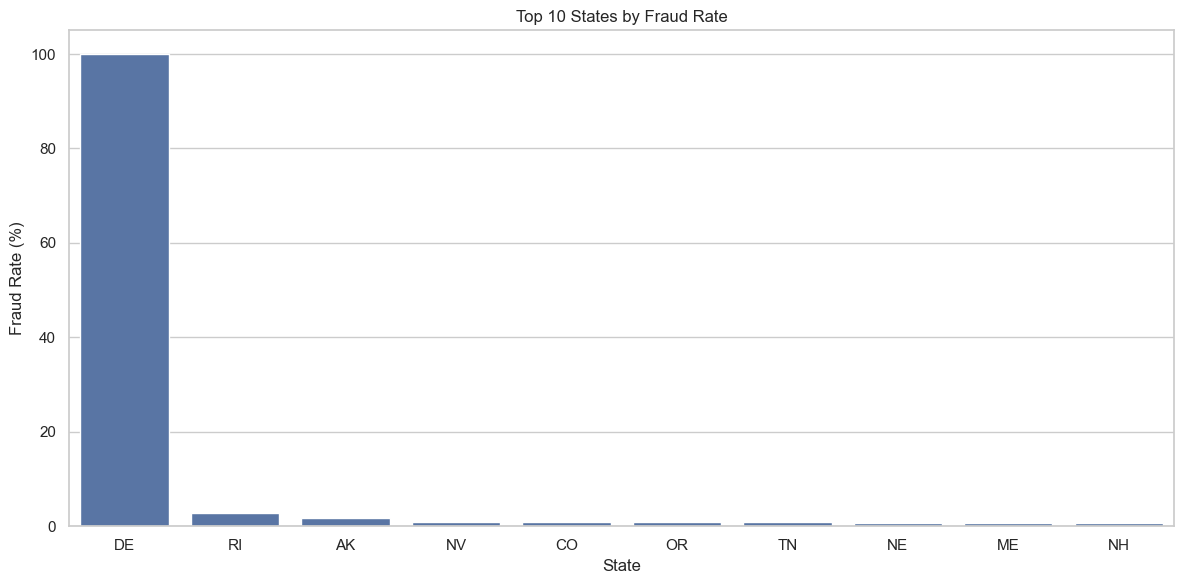

In [40]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=state_fraud.head(10),
    x="state",
    y="fraud_rate_percent"
)

plt.title("Top 10 States by Fraud Rate")
plt.xlabel("State")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

In [41]:
df["amount_range"] = pd.cut(
    df["amt"],
    bins=[0, 25, 50, 100, 250, 500, 1000, np.inf],
    labels=[
        "0-25",
        "25-50",
        "50-100",
        "100-250",
        "250-500",
        "500-1000",
        "1000+"
    ]
)

In [42]:
amount_fraud = (
    df.groupby("amount_range", observed=False)["is_fraud"]
      .mean()
      .reset_index()
)

amount_fraud["fraud_rate_percent"] = (
    amount_fraud["is_fraud"] * 100
)

amount_fraud

,amount_range,is_fraud,fraud_rate_percent
0,0-25,0.003348,0.334803
1,25-50,0.000263,0.026348
2,50-100,0.000116,0.011554
3,100-250,0.001242,0.124214
4,250-500,0.085951,8.595085
5,500-1000,0.230782,23.078239
6,1000+,0.241108,24.110772


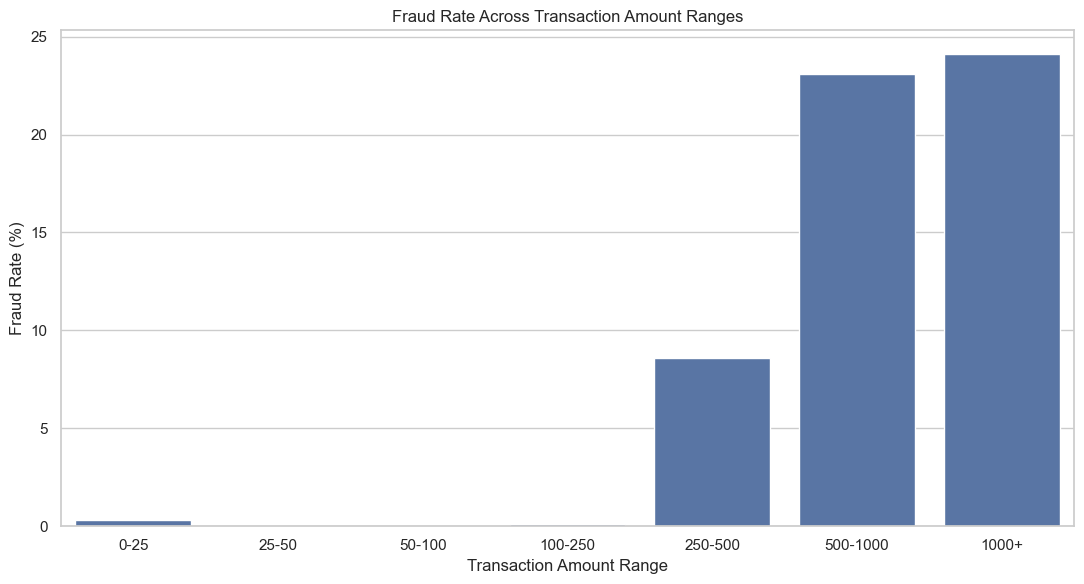

In [43]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=amount_fraud,
    x="amount_range",
    y="fraud_rate_percent"
)

plt.title("Fraud Rate Across Transaction Amount Ranges")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

In [44]:
print("Overall Fraud Rate:")
print(f"{df['is_fraud'].mean() * 100:.4f}%")

print("\nAverage Transaction Amount:")
print(f"${df['amt'].mean():.2f}")

print("\nAverage Fraudulent Transaction Amount:")
print(
    f"${df.loc[df['is_fraud'] == 1, 'amt'].mean():.2f}"
)

print("\nAverage Legitimate Transaction Amount:")
print(
    f"${df.loc[df['is_fraud'] == 0, 'amt'].mean():.2f}"
)

print("\nAverage Customer-Merchant Distance:")
print(
    f"{df['customer_merchant_distance_km'].mean():.2f} km"
)

print("\nAverage Distance for Fraudulent Transactions:")
print(
    f"{df.loc[df['is_fraud'] == 1, 'customer_merchant_distance_km'].mean():.2f} km"
)

print("\nAverage Distance for Legitimate Transactions:")
print(
    f"{df.loc[df['is_fraud'] == 0, 'customer_merchant_distance_km'].mean():.2f} km"
)

Overall Fraud Rate:
0.5789%

Average Transaction Amount:
$70.35

Average Fraudulent Transaction Amount:
$531.32

Average Legitimate Transaction Amount:
$67.67

Average Customer-Merchant Distance:
76.11 km

Average Distance for Fraudulent Transactions:
76.27 km

Average Distance for Legitimate Transactions:
76.11 km


# 6. Key Findings

The exploratory analysis provides several insights into the structure and patterns of the credit card transaction data.

### Dataset and Data Quality
- The training dataset contains 1,296,675 transaction records and 23 columns.
- The dataset contains no missing values based on the performed missing-value check.
- No duplicate rows were identified.

### Transaction Patterns
- Transaction amount distributions were compared between legitimate and fraudulent transactions.
- Fraud rates were examined across transaction categories and amount ranges.

### Temporal Patterns
- Transaction timestamps were transformed into hour, day, month, and day-of-week variables.
- Fraud rates were analyzed across hours and days to identify temporal variations.

### Geographic Patterns
- Customer and merchant coordinates were used to derive customer–merchant distance.
- Geographic distance was compared between legitimate and fraudulent transactions.

### Overall Conclusion
The EDA provides a multidimensional understanding of transaction behaviour and fraud-related patterns. These findings can be used to guide subsequent feature engineering, visualization, and machine-learning stages of the credit card fraud detection project.

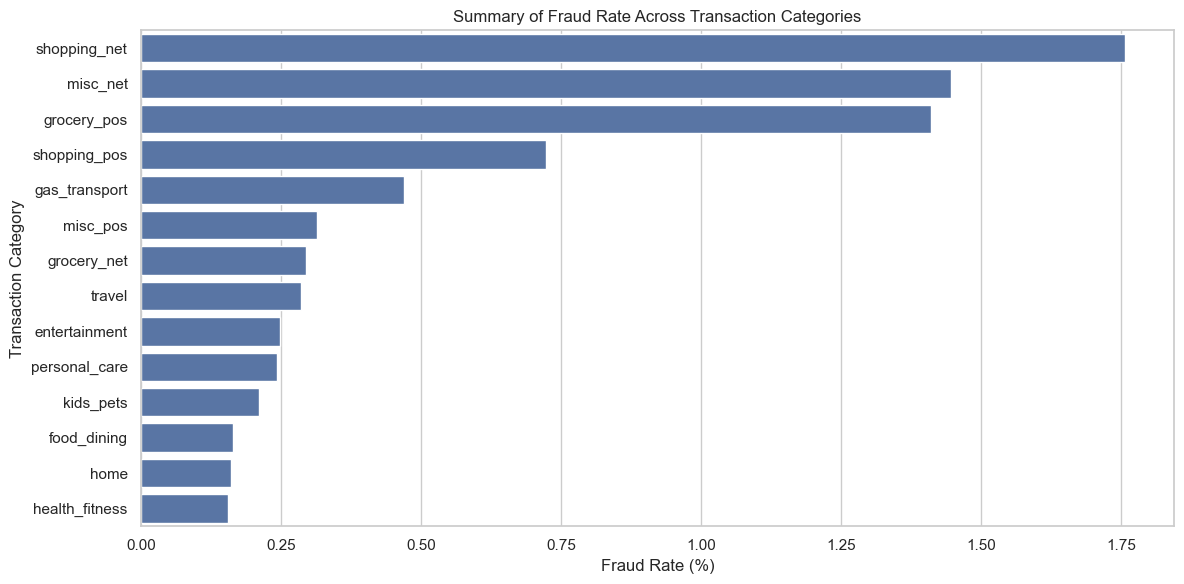

In [45]:
summary_category = (
    df.groupby("category")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=summary_category.values,
    y=summary_category.index
)

plt.title("Summary of Fraud Rate Across Transaction Categories")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Category")

plt.tight_layout()
plt.show()

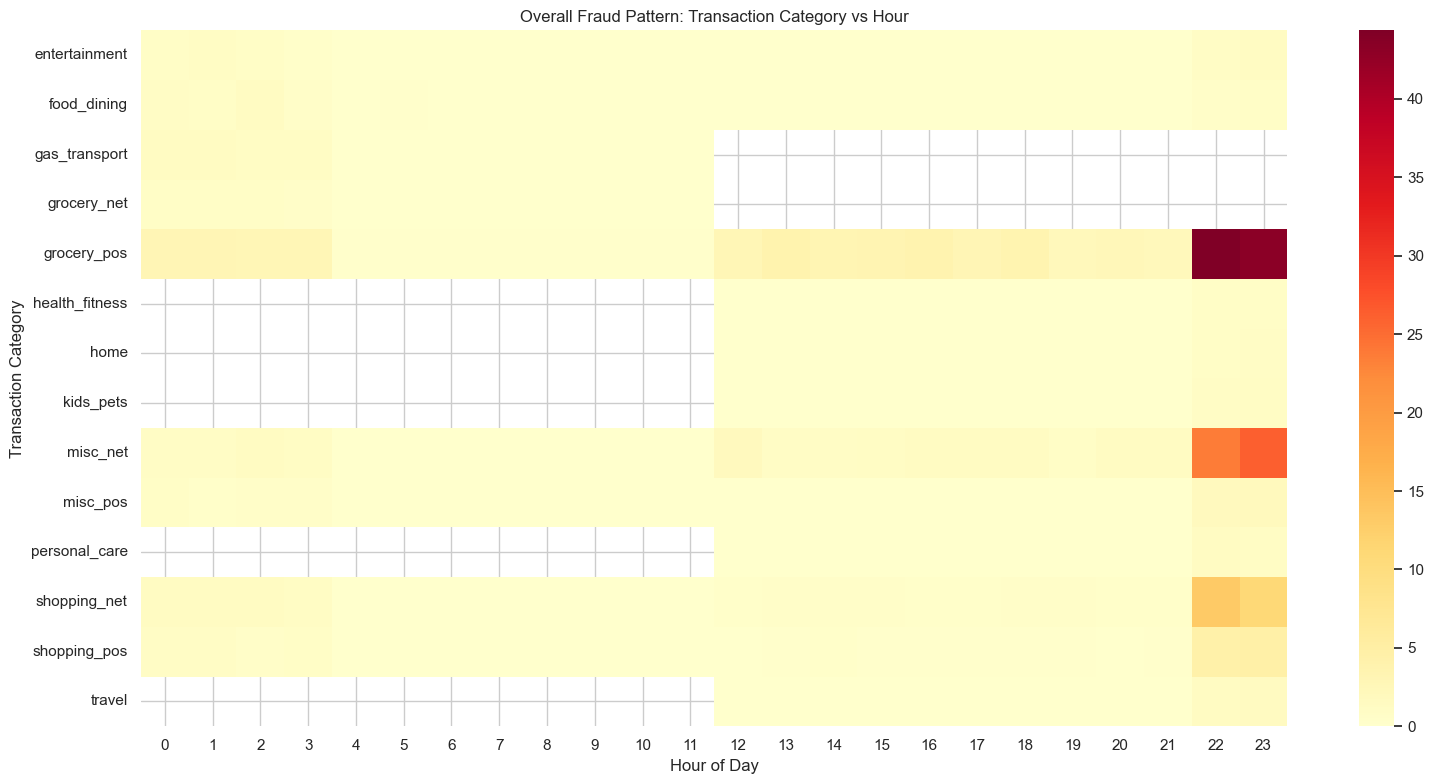

In [46]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False
)

plt.title("Overall Fraud Pattern: Transaction Category vs Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Category")

plt.tight_layout()
plt.show()